In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\Asus\\.matplotlib\\fontlist-v390.json.matplotlib-lock'


In [4]:
train_data_path = "../data/credit/train.csv"
test_data_path = "../data/credit/test.csv"

train_df = pd.read_csv(train_data_path,low_memory=False)
test_df = pd.read_csv(test_data_path,low_memory=False)


print(f"Train dataset shape: {train_df.shape[0]} rows, {train_df.shape[1]} columns")
print(f"Test dataset shape: {test_df.shape[0]} rows, {test_df.shape[1]} columns")

Train dataset shape: 100000 rows, 28 columns
Test dataset shape: 50000 rows, 27 columns


**Exploratory data analysis for training dataset**

In [5]:
df_train = train_df.copy()
df_test = test_df.copy()
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [6]:
#Identifying initial categorical and numerical features
num_features = [col for col in df_train.columns if pd.api.types.is_numeric_dtype(df_train[col]) and col != 'Credit_Score']
cat_features = [col for col in df_train.columns if not pd.api.types.is_numeric_dtype(df_train[col]) and col != 'Credit_Score']

print(f"Numerical Features:\n", num_features, "\n")
print(f"Categorical Features:\n", cat_features)

Numerical Features:
 ['Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Delay_from_due_date', 'Num_Credit_Inquiries', 'Credit_Utilization_Ratio', 'Total_EMI_per_month'] 

Categorical Features:
 ['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income', 'Num_of_Loan', 'Type_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Credit_Mix', 'Outstanding_Debt', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance']


**Target variable distribution**

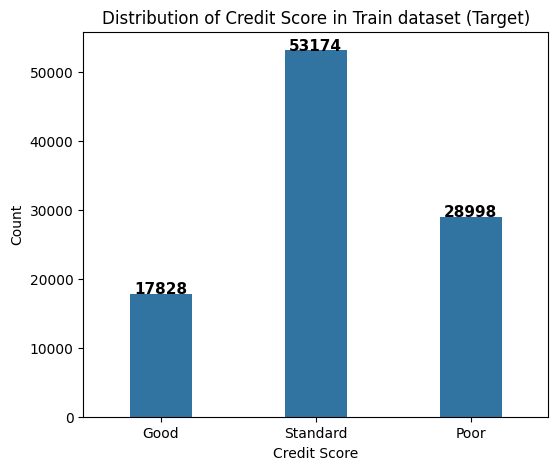

Target Distribution:
Credit_Score
Good        17.828
Poor        28.998
Standard    53.174
Name: proportion, dtype: float64


In [15]:
plt.figure(figsize=(6,5))
ax = sns.countplot(x='Credit_Score', data=df_train,width=0.4)
plt.title('Distribution of Credit Score in Train dataset (Target)')
plt.xlabel('Credit Score')
plt.ylabel('Count')

# Annotate counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2.,p.get_height()+5),ha='center',va='baseline',fontsize=11, fontweight='bold')
plt.show()

# Print Distribution
print('Target Distribution:')
print(df_train['Credit_Score'].value_counts(normalize=True).sort_index(ascending=True)*100)

**Auditing Missing Values**

In [9]:
missing_count = df_train.isnull().sum()
missing_percent = df_train.isnull().mean() * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': missing_percent
})

# Show only columns with missing values, sorted
missing_summary = missing_summary[missing_summary['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)
display(missing_summary)

,Missing Count,Missing Percentage (%)
Monthly_Inhand_Salary,15002,15.002
Type_of_Loan,11408,11.408
Name,9985,9.985
Credit_History_Age,9030,9.030
Num_of_Delayed_Payment,7002,7.002
Amount_invested_monthly,4479,4.479
Num_Credit_Inquiries,1965,1.965
Monthly_Balance,1200,1.200


**Data cleaning and preprocessing**

In [10]:
##------Age------------------##

for df in [df_train, df_test]:
    df['Age'] = df['Age'].astype(str).str.replace('_', '', regex=False)
    df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
    
    #Handle explicitly invalid negative values
    df.loc[(df['Age']>=90) | (df['Age'] < 0), 'Age'] = np.nan

print(f"Summary of 'Age' after processing for train dataset:")
display(df_train['Age'].describe())
print("-" * 70) # Separator for readability

Summary of 'Age' after processing for train dataset:


count    97219.000000
mean        33.320009
std         10.769558
min         14.000000
25%         24.000000
50%         33.000000
75%         42.000000
max         56.000000
Name: Age, dtype: float64

----------------------------------------------------------------------


In [11]:
##--------Annual Income-------##

for df in [df_train,df_test]:
    # Handle string cleaning and conversion to numeric
    df['Annual_Income'] = df['Annual_Income'].astype(str).str.replace('_', '', regex=False)
    df['Annual_Income'] = pd.to_numeric(df['Annual_Income'], errors='coerce')

print(f"Summary of 'Annual_Income' after processing for train dataset:")
display(df_train['Annual_Income'].describe())
print("-" * 70)

Summary of 'Annual_Income' after processing for train dataset:


count    1.000000e+05
mean     1.764157e+05
std      1.429618e+06
min      7.005930e+03
25%      1.945750e+04
50%      3.757861e+04
75%      7.279092e+04
max      2.419806e+07
Name: Annual_Income, dtype: float64

----------------------------------------------------------------------


In [12]:
##-------Monthly Inhand Salary-----------##

for df in [df_train,df_test]:
    # Handle string cleaning (if any) and conversion to numeric (already float64, but for consistency)
    df['Monthly_Inhand_Salary'] = pd.to_numeric(df['Monthly_Inhand_Salary'], errors='coerce')
    
    # Handle explicitly invalid negative values
    df.loc[(df['Monthly_Inhand_Salary'] < 0), 'Monthly_Inhand_Salary'] = np.nan
    
    # Calculate IQR and bounds for outliers
    Q1 = df['Monthly_Inhand_Salary'].dropna().quantile(0.25)
    Q3 = df['Monthly_Inhand_Salary'].dropna().quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Replace outliers with NaN
    initial_nan_count_before_iqr = df['Monthly_Inhand_Salary'].isnull().sum()
    df.loc[(df['Monthly_Inhand_Salary'] < lower_bound) | (df['Monthly_Inhand_Salary'] > upper_bound), 'Monthly_Inhand_Salary'] = np.nan
    final_nan_count_after_iqr = df['Monthly_Inhand_Salary'].isnull().sum()
    
# Print summary for the processed column
print(f"Summary of 'Monthly_Inhand_Salary' after processing for train dataset:")
display(df_train['Monthly_Inhand_Salary'].describe())
print("-" * 70)

Summary of 'Monthly_Inhand_Salary' after processing for train dataset:


count    83315.000000
mean      3999.762856
std       2901.824960
min        303.645417
25%       1612.487500
50%       3038.445000
75%       5783.456667
max      12452.330000
Name: Monthly_Inhand_Salary, dtype: float64

----------------------------------------------------------------------


In [13]:
##----- Num_Bank_Accounts------------------##

for df in [df_train,df_test]:
    df['Num_Bank_Accounts'] = pd.to_numeric(df['Num_Bank_Accounts'], errors='coerce')
    
    # Handle explicitly invalid negative values
    df.loc[(df['Num_Bank_Accounts'] < 0), 'Num_Bank_Accounts'] = np.nan
    
    # Calculate IQR and bounds for outliers
    Q1 = df['Num_Bank_Accounts'].dropna().quantile(0.25)
    Q3 = df['Num_Bank_Accounts'].dropna().quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Replace outliers with NaN
    initial_nan_count_before_iqr = df['Num_Bank_Accounts'].isnull().sum()
    df.loc[(df['Num_Bank_Accounts'] < lower_bound) | (df['Num_Bank_Accounts'] > upper_bound), 'Num_Bank_Accounts'] = np.nan
    final_nan_count_after_iqr = df['Num_Bank_Accounts'].isnull().sum()
    

print(f"Summary of 'Num_Bank_Accounts' after processing for train dataset:")
display(df_train['Num_Bank_Accounts'].describe())
print("-" * 70)

Summary of 'Num_Bank_Accounts' after processing for train dataset:


count    98664.000000
mean         5.368980
std          2.592451
min          0.000000
25%          3.000000
50%          5.000000
75%          7.000000
max         11.000000
Name: Num_Bank_Accounts, dtype: float64

----------------------------------------------------------------------


In [14]:
##------------------Num_Credit_Card------------------##

for df in [df_train,df_test]:
    # Handle string cleaning (if any) and conversion to numeric (already int64, but for consistency)
    df['Num_Credit_Card'] = pd.to_numeric(df['Num_Credit_Card'], errors='coerce')
    
    # Handle explicitly invalid negative values
    df.loc[(df['Num_Credit_Card'] < 0), 'Num_Credit_Card'] = np.nan
    
    # Calculate IQR and bounds for outliers
    Q1 = df['Num_Credit_Card'].dropna().quantile(0.25)
    Q3 = df['Num_Credit_Card'].dropna().quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Replace outliers with NaN
    initial_nan_count_before_iqr = df['Num_Credit_Card'].isnull().sum()
    df.loc[(df['Num_Credit_Card'] < lower_bound) | (df['Num_Credit_Card'] > upper_bound), 'Num_Credit_Card'] = np.nan
    final_nan_count_after_iqr = df['Num_Credit_Card'].isnull().sum()

print(f"Summary of 'Num_Credit_Card' after processing for train dataset:")
display(df_train['Num_Credit_Card'].describe())
print("-" * 70)

Summary of 'Num_Credit_Card' after processing for train dataset:


count    97729.000000
mean         5.533322
std          2.067703
min          0.000000
25%          4.000000
50%          5.000000
75%          7.000000
max         11.000000
Name: Num_Credit_Card, dtype: float64

----------------------------------------------------------------------


In [26]:
##-----Interest_Rate-------------------##

for df in [df_train,df_test]:
    # Handle string cleaning (if any) and conversion to numeric (already int64, but for consistency)
    df['Interest_Rate'] = pd.to_numeric(df['Interest_Rate'], errors='coerce')
    
    # Handle explicitly invalid negative values
    df.loc[(df['Interest_Rate'] < 0), 'Interest_Rate'] = np.nan
    
    # Calculate IQR and bounds for outliers
    Q1 = df['Interest_Rate'].dropna().quantile(0.25)
    Q3 = df['Interest_Rate'].dropna().quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Replace outliers with NaN
    initial_nan_count_before_iqr = df['Interest_Rate'].isnull().sum()
    df.loc[(df['Interest_Rate'] < lower_bound) | (df['Interest_Rate'] > upper_bound), 'Interest_Rate'] = np.nan
    final_nan_count_after_iqr = df['Interest_Rate'].isnull().sum()
    
print(f"Summary of 'Interest_Rate' after processing for train dataset:")
display(df_train['Interest_Rate'].describe())
print("-" * 70)

Summary of 'Interest_Rate' after processing:


count    97966.000000
mean        14.531603
std          8.739748
min          1.000000
25%          7.000000
50%         13.000000
75%         20.000000
max         34.000000
Name: Interest_Rate, dtype: float64

----------------------------------------------------------------------


In [16]:
##------------- Num_of_Loan------------------------##

for df in [df_train,df_test]:
    # Handle string cleaning and conversion to numeric
    df['Num_of_Loan'] = df['Num_of_Loan'].astype(str).str.replace('_', '', regex=False)
    df['Num_of_Loan'] = pd.to_numeric(df['Num_of_Loan'], errors='coerce')
    
    # Handle explicitly invalid negative values
    df.loc[(df['Num_of_Loan'] < 0), 'Num_of_Loan'] = np.nan
    
    # Calculate IQR and bounds for outliers
    Q1 = df['Num_of_Loan'].dropna().quantile(0.25)
    Q3 = df['Num_of_Loan'].dropna().quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Replace outliers with NaN
    initial_nan_count_before_iqr = df['Num_of_Loan'].isnull().sum()
    df.loc[(df['Num_of_Loan'] < lower_bound) | (df['Num_of_Loan'] > upper_bound), 'Num_of_Loan'] = np.nan
    final_nan_count_after_iqr = df['Num_of_Loan'].isnull().sum()

print(f"Summary of 'Num_of_Loan' after processing for train dataset:")
display(df_train['Num_of_Loan'].describe())
print("-" * 70)

Summary of 'Num_of_Loan' after processing for train dataset:


count    95652.000000
mean         3.533758
std          2.447308
min          0.000000
25%          2.000000
50%          3.000000
75%          5.000000
max          9.000000
Name: Num_of_Loan, dtype: float64

----------------------------------------------------------------------


In [17]:
##--------------Delay_from_due_date-------------------------##

for df in [df_train,df_test]:
    # Handle string cleaning (if any) and conversion to numeric (already int64, but for consistency)
    df['Delay_from_due_date'] = pd.to_numeric(df['Delay_from_due_date'], errors='coerce')
    
    # Handle explicitly invalid negative values
    df['Delay_from_due_date'] = df['Delay_from_due_date'].clip(lower=0)


print(f"Summary of 'Delay_from_due_date' after processing for train dataset:")
display(df_train['Delay_from_due_date'].describe())
print("-" * 70)

Summary of 'Delay_from_due_date' after processing for train dataset:


count    100000.000000
mean         21.081910
std          14.840204
min           0.000000
25%          10.000000
50%          18.000000
75%          28.000000
max          67.000000
Name: Delay_from_due_date, dtype: float64

----------------------------------------------------------------------


In [18]:
##--------------Num_of_Delayed_Payment----------------------##

for df in [df_train,df_test]:
    # Handle string cleaning and conversion to numeric
    df['Num_of_Delayed_Payment'] = df['Num_of_Delayed_Payment'].astype(str).str.replace('_', '', regex=False)
    df['Num_of_Delayed_Payment'] = pd.to_numeric(df['Num_of_Delayed_Payment'], errors='coerce')
    
    # Handle explicitly invalid negative values
    df.loc[(df['Num_of_Delayed_Payment'] < 0), 'Num_of_Delayed_Payment'] = np.nan
    
    # Calculate IQR and bounds for outliers
    Q1 = df['Num_of_Delayed_Payment'].dropna().quantile(0.25)
    Q3 = df['Num_of_Delayed_Payment'].dropna().quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Replace outliers with NaN
    initial_nan_count_before_iqr = df['Num_of_Delayed_Payment'].isnull().sum()
    df.loc[(df['Num_of_Delayed_Payment'] < lower_bound) | (df['Num_of_Delayed_Payment'] > upper_bound), 'Num_of_Delayed_Payment'] = np.nan
    final_nan_count_after_iqr = df['Num_of_Delayed_Payment'].isnull().sum()
    

print(f"Summary of 'Num_of_Delayed_Payment' after processing for train dataset:")
display(df_train['Num_of_Delayed_Payment'].describe())
print("-" * 70)

Summary of 'Num_of_Delayed_Payment' after processing for train dataset:


count    91618.000000
mean        13.419634
std          6.207354
min          0.000000
25%          9.000000
50%         14.000000
75%         18.000000
max         28.000000
Name: Num_of_Delayed_Payment, dtype: float64

----------------------------------------------------------------------


In [19]:
##------------Changed_credit_Limit--------------------------------##

for df in [df_train,df_test]:
    # Handle string cleaning and conversion to numeric
    df['Changed_Credit_Limit'] = df['Changed_Credit_Limit'].astype(str).str.replace('_', '', regex=False).str.strip()
    df['Changed_Credit_Limit'] = pd.to_numeric(df['Changed_Credit_Limit'], errors='coerce')
    
    # Changed_Credit_Limit can be negative, so no general negative value handling
    df['Changed_Credit_Limit'] = df['Changed_Credit_Limit'].round(2)
    
    # Vectorized filtering
    df.loc[df['Changed_Credit_Limit'] > 100, 'Changed_Credit_Limit'] = np.nan


print(f"Summary of 'Changed_Credit_Limit' after processing for train dataset:")
display(df_train['Changed_Credit_Limit'].describe())
print("-" * 70)

Summary of 'Changed_Credit_Limit' after processing for train dataset:


count    97909.000000
mean        10.389025
std          6.789496
min         -6.490000
25%          5.320000
50%          9.400000
75%         14.870000
max         36.970000
Name: Changed_Credit_Limit, dtype: float64

----------------------------------------------------------------------


In [20]:
#------Num_Credit_Inquiries------------------#

for df in [df_train,df_test]:
    # Handle string cleaning (if any) and conversion to numeric (already float64, but for consistency)
    df['Num_Credit_Inquiries'] = pd.to_numeric(df['Num_Credit_Inquiries'], errors='coerce')
    
    # Handle explicitly invalid negative values
    df.loc[(df['Num_Credit_Inquiries'] < 0)  | (df['Num_Credit_Inquiries'] > 25), 'Num_Credit_Inquiries'] = np.nan


print(f"Summary of 'Num_Credit_Inquiries' after processing for train datset:")
display(df_train['Num_Credit_Inquiries'].describe())
print("-" * 70)

Summary of 'Num_Credit_Inquiries' after processing for train datset:


count    96385.000000
mean         5.781117
std          3.860712
min          0.000000
25%          3.000000
50%          5.000000
75%          8.000000
max         17.000000
Name: Num_Credit_Inquiries, dtype: float64

----------------------------------------------------------------------


In [21]:
##--------Credit_Utilization_Ratio--------------##

for df in [df_train,df_test]:
    # Handle string cleaning (if any) and conversion to numeric (already float64, but for consistency)
    df['Credit_Utilization_Ratio'] = pd.to_numeric(df['Credit_Utilization_Ratio'], errors='coerce')
    
    # Handle explicitly invalid negative values
    df.loc[(df['Credit_Utilization_Ratio'] < 0), 'Credit_Utilization_Ratio'] = np.nan
    
    # Calculate IQR and bounds for outliers
    Q1 = df['Credit_Utilization_Ratio'].dropna().quantile(0.25)
    Q3 = df['Credit_Utilization_Ratio'].dropna().quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Replace outliers with NaN
    initial_nan_count_before_iqr = df['Credit_Utilization_Ratio'].isnull().sum()
    df.loc[(df['Credit_Utilization_Ratio'] < lower_bound) | (df['Credit_Utilization_Ratio'] > upper_bound), 'Credit_Utilization_Ratio'] = np.nan
    final_nan_count_after_iqr = df['Credit_Utilization_Ratio'].isnull().sum()


print(f"Summary of 'Credit_Utilization_Ratio' after processing for train dataset:")
display(df_train['Credit_Utilization_Ratio'].describe())
print("-" * 70)

Summary of 'Credit_Utilization_Ratio' after processing for train dataset:


count    99996.000000
mean        32.284480
std          5.115807
min         20.000000
25%         28.052509
50%         32.305569
75%         36.496206
max         49.064277
Name: Credit_Utilization_Ratio, dtype: float64

----------------------------------------------------------------------


In [22]:
#-----------------Total_EMI_per_month------------------------##

for df in [df_train,df_test]:
    # Handle string cleaning (if any) and conversion to numeric (already float64, but for consistency)
    df['Total_EMI_per_month'] = pd.to_numeric(df['Total_EMI_per_month'], errors='coerce')
    
    # Handle explicitly invalid negative values
    df.loc[(df['Total_EMI_per_month'] < 0) | (df['Total_EMI_per_month'] > 10000), 'Total_EMI_per_month'] = np.nan

print(f"Summary of 'Total_EMI_per_month' after processing for train dataset:")
display(df_train['Total_EMI_per_month'].describe())
print("-" * 70)

Summary of 'Total_EMI_per_month' after processing for train dataset:


count    97194.000000
mean       125.787679
std        371.820215
min          0.000000
25%         29.422247
50%         66.750201
75%        148.655532
max       9997.000000
Name: Total_EMI_per_month, dtype: float64

----------------------------------------------------------------------


In [23]:
##-----------Amount_invested_monthly-------------------##

for df in [df_train,df_test]:
    
    # Handle string cleaning and conversion to numeric
    df['Amount_invested_monthly'] = df['Amount_invested_monthly'].astype(str).str.replace('_', '', regex=False)
    df['Amount_invested_monthly'] = pd.to_numeric(df['Amount_invested_monthly'], errors='coerce')
    
    # Handle explicitly invalid negative values
    df.loc[(df['Amount_invested_monthly'] < 0), 'Amount_invested_monthly'] = np.nan


print(f"Summary of 'Amount_invested_monthly' after processing for train dataset:")
display(df_train['Amount_invested_monthly'].describe())
print("-" * 70)

Summary of 'Amount_invested_monthly' after processing for train dataset:


count    95521.000000
mean       637.412998
std       2043.319327
min          0.000000
25%         74.534002
50%        135.925682
75%        265.731733
max      10000.000000
Name: Amount_invested_monthly, dtype: float64

----------------------------------------------------------------------


In [24]:
##--------------- Monthly_Balance------------------##

for df in [df_train,df_test]:
    # Handle string cleaning and conversion to numeric
    df['Monthly_Balance'] = df['Monthly_Balance'].astype(str).str.replace('_', '', regex=False)
    df['Monthly_Balance'] = pd.to_numeric(df['Monthly_Balance'], errors='coerce')
    
    # Monthly_Balance can be negative, so no general negative value handling
    df['Monthly_Balance'] = pd.to_numeric(df['Monthly_Balance'], errors='coerce')
    # Vectorized out-of-bounds removal
    df.loc[df['Monthly_Balance'] < -10000, 'Monthly_Balance'] = np.nan

print(f"Summary of 'Monthly_Balance' after processing for train dataset:")
display(df_train['Monthly_Balance'].describe())
print("-" * 70)

Summary of 'Monthly_Balance' after processing for train dataset:


count    98791.000000
mean       402.551258
std        213.925499
min          0.007760
25%        270.106630
50%        336.731225
75%        470.262938
max       1602.040519
Name: Monthly_Balance, dtype: float64

----------------------------------------------------------------------


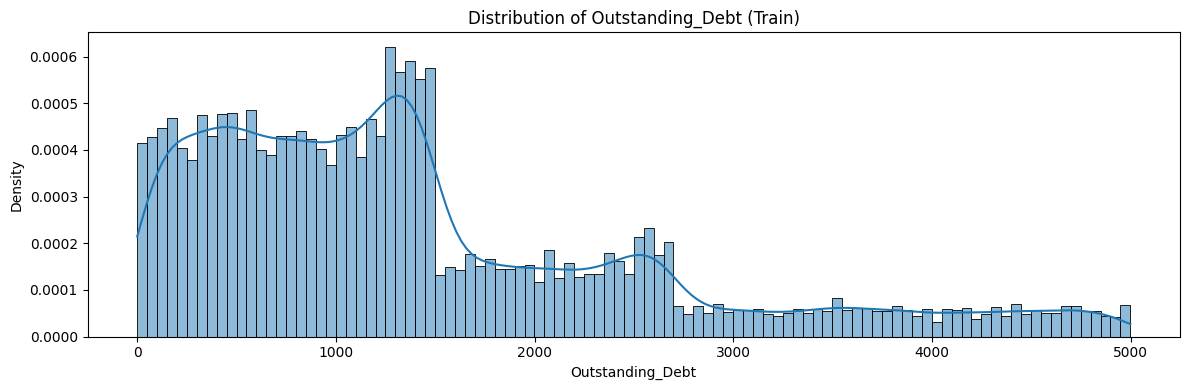

In [25]:
##--------------Outstanding_Debt----------------------------##

for df in [df_train,df_test]:
    df['Outstanding_Debt'] = df['Outstanding_Debt'].astype(str).str.replace('_', '', regex=False).str.strip()
    df['Outstanding_Debt'] = pd.to_numeric(df['Outstanding_Debt'], errors='coerce')

# Plotting the distribution
fig, ax = plt.subplots(figsize=(12, 4))
sns.histplot(
    df_train[df_train['Outstanding_Debt'] <= 5000]['Outstanding_Debt'],
    kde=True,
    ax=ax,
    bins=100,
    stat='density'
)
ax.set_title('Distribution of Outstanding_Debt (Train)')
ax.set_xlabel('Outstanding_Debt')
ax.set_ylabel('Density')
plt.tight_layout()
plt.show()

In [26]:
##---------------Credit_History_Age-------------------------##

for df in [df_train,df_test]:
    split_df = df['Credit_History_Age'].str.strip().str.split(' ', expand=True)
    years = pd.to_numeric(split_df[0], errors='coerce')
    months = pd.to_numeric(split_df[3], errors='coerce')
    df['Credit_History_Age_Total'] = years * 12 + months
    df.drop(columns=['Credit_History_Age'], inplace=True, errors='ignore')

print("Credit_History_Age converted to months. Summary for train dataset:")
print(df_train['Credit_History_Age_Total'].describe())

Credit_History_Age converted to months. Summary for train dataset:
count    90970.000000
mean       221.195405
std         99.741364
min          1.000000
25%        144.000000
50%        219.000000
75%        302.000000
max        404.000000
Name: Credit_History_Age_Total, dtype: float64


In [27]:
##----------Occupation------------------##
for df in [df_train,df_test]:
    df['Occupation'] = df['Occupation'].replace('_______', 'Unknown')

print("Occupation value counts (Train):")
print(df_train['Occupation'].value_counts())

Occupation value counts (Train):
Occupation
Unknown          7062
Lawyer           6575
Architect        6355
Engineer         6350
Scientist        6299
Mechanic         6291
Accountant       6271
Developer        6235
Media_Manager    6232
Teacher          6215
Entrepreneur     6174
Doctor           6087
Journalist       6085
Manager          5973
Musician         5911
Writer           5885
Name: count, dtype: int64


In [28]:
#-------------------Type_of_Loan-----------------------------##

from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer

for df in [df_train,df_test]:
    df['Type_of_Loan'] = df['Type_of_Loan'].fillna('Unknown Loan')
    # Replace 'and' with comma to split cleanly
    cleaned = df['Type_of_Loan'].astype(str).str.replace(r'\band\b', ',', regex=True)
    df['Type_of_Loan_Clean'] = cleaned.str.split(r',\s*')
    df['Type_of_Loan_Clean'] = df['Type_of_Loan_Clean'].apply(
            lambda d: [x.strip() for x in d if x.strip()] if isinstance(d, list) else ['Unknown Loan']
        )

# Fit MultiLabelBinarizer on training set
mlb = MultiLabelBinarizer()
train_loan_encoded = pd.DataFrame(
    mlb.fit_transform(df['Type_of_Loan_Clean']),
    columns=mlb.classes_,
    index=df.index
)
test_loan_encoded = pd.DataFrame(
    mlb.transform(df_test['Type_of_Loan_Clean']), 
    columns=mlb.classes_, 
    index=df_test.index
)

df_train = pd.concat([df_train, train_loan_encoded], axis=1)
df_test = pd.concat([df_test, test_loan_encoded], axis=1)

columns_to_drop = ['Type_of_Loan', 'Type_of_Loan_Clean']
df_train.drop(columns=columns_to_drop, inplace=True, errors='ignore')
df_test.drop(columns=columns_to_drop, inplace=True, errors='ignore')

print(f"Type_of_Loan binarized. Added {len(mlb.classes_)} new binary columns:", list(mlb.classes_))

Type_of_Loan binarized. Added 10 new binary columns: ['Auto Loan', 'Credit-Builder Loan', 'Debt Consolidation Loan', 'Home Equity Loan', 'Mortgage Loan', 'Not Specified', 'Payday Loan', 'Personal Loan', 'Student Loan', 'Unknown Loan']


In [29]:
##------------------Credit_Mix--------------##

for df in [df_train,df_test]:
    df['Credit_Mix'] = df['Credit_Mix'].str.replace('_', 'Unknown Credit Mix')

print("Credit_Mix value counts for train dataset:")
print(df_train['Credit_Mix'].value_counts())

Credit_Mix value counts for train dataset:
Credit_Mix
Standard              36479
Good                  24337
Unknown Credit Mix    20195
Bad                   18989
Name: count, dtype: int64


In [30]:
##---------------Payment_of_Min_Amount------------------##

for df in [df_train,df_test]:
    df[['Payment_of_Min_Amount']].value_counts()
    
    df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].replace('NM', 'No')

print("Payment_of_Min_Amount value counts for train dataset:")
print(df_train['Payment_of_Min_Amount'].value_counts())

Payment_of_Min_Amount value counts for train dataset:
Payment_of_Min_Amount
Yes    52326
No     47674
Name: count, dtype: int64


In [31]:
##---------------Payment_Behavior----------------------------#

for df in [df_train,df_test]:
    df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8', 'Unknown')

print("Payment_Behaviour value counts for train dataset:")
print(df_train['Payment_Behaviour'].value_counts())

Payment_Behaviour value counts for train dataset:
Payment_Behaviour
Low_spent_Small_value_payments      25513
High_spent_Medium_value_payments    17540
Low_spent_Medium_value_payments     13861
High_spent_Large_value_payments     13721
High_spent_Small_value_payments     11340
Low_spent_Large_value_payments      10425
Unknown                              7600
Name: count, dtype: int64


In [32]:
##----------------Imputation-----------------------------##

from sklearn.impute import SimpleImputer
# Map target variable mapping beforehand to avoid issues
target_map = {'Poor': 1, 'Standard': 0, 'Good': 0}
df_train['Credit_Score'] = df_train['Credit_Score'].map(target_map)

df_train1 = df_train.copy()
# Identify numeric vs categorical columns robustly
cat_cols = [col for col in df_train.columns if not pd.api.types.is_numeric_dtype(df_train[col]) and col != 'Credit_Score']
num_cols = [col for col in df_train.columns if pd.api.types.is_numeric_dtype(df_train[col]) and col != 'Credit_Score' and col not in mlb.classes_]

# Numerical Imputer (fit on train only)
num_imputer = SimpleImputer(strategy='median')
df_train1[num_cols] = num_imputer.fit_transform(df_train[num_cols])
df_test[num_cols] = num_imputer.fit_transform(df_test[num_cols])

# Categorical Imputer (fit on train only)
if len(cat_cols) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df_train1[cat_cols] = cat_imputer.fit_transform(df_train[cat_cols])
    df_test[cat_cols] = cat_imputer.fit_transform(df_test[cat_cols])

print(f"Numerical columns imputed: {num_cols}\n")
print(f"Categorical columns imputed: {cat_cols}")
print(f"Missing values remaining in Train: {df_train1[num_cols + cat_cols].isnull().sum().sum()}")


Numerical columns imputed: ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Credit_History_Age_Total']

Categorical columns imputed: ['ID', 'Customer_ID', 'Month', 'Name', 'SSN', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
Missing values remaining in Train: 0


In [33]:
df_train1.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Auto Loan,Credit-Builder Loan,Debt Consolidation Loan,Home Equity Loan,Mortgage Loan,Not Specified,Payday Loan,Personal Loan,Student Loan,Unknown Loan
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3.0,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,3038.445000,3.0,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0x1604,CUS_0xd40,March,Aaron Maashoh,33.0,821-00-0265,Scientist,19114.12,3038.445000,3.0,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,3038.445000,3.0,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
df_train1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 37 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  float64
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  float64
 10  Num_Credit_Card           100000 non-null  float64
 11  Interest_Rate             100000 non-null  float64
 12  Num_of_Loan               100000 non-null  float64
 13  Delay_from_due_date       100000 non-null  fl

In [44]:
from pathlib import Path

# Create the output directory
output_dir = Path("../data") / "cleaned_credit"
output_dir.mkdir(parents=True, exist_ok=True)

# Save the cleaned DataFrames
df_train1.to_csv(output_dir / "cleaned_train.csv", index=False)
df_test.to_csv(output_dir / "cleaned_test.csv", index=False)

print(f"Cleaned train data saved to: {output_dir / 'cleaned_train.csv'}")
print(f"Cleaned test data saved to: {output_dir / 'cleaned_test.csv'}")

Cleaned train data saved to: ..\data\cleaned_credit\cleaned_train.csv
Cleaned test data saved to: ..\data\cleaned_credit\cleaned_test.csv
